# Exploratory Data Analysis  EV Service Intelligence

## Objective

The objective of this notebook is to understand the EV service dataset
before machine learning.

We will focus on:

- Understanding the dataset structure
- Checking data quality
- Understanding the target variables
- Identifying important business patterns
- Finding relationships that may be useful for machine learning

### Scope

This notebook is for analysis only.

No permanent changes are made to the raw dataset.
Feature engineering and ML preparation will be performed separately.

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns 
import plotly.express as px

In [2]:
sns.set_theme(
    style="whitegrid",
    context="notebook"
)

In [3]:
df = pd.read_csv("ev_service_history_raw.csv")

In [4]:
df.shape

(6583, 41)

In [5]:
df.head()

,Vehicle_ID,Visit_Number,Purchase_Date,Service_Date,Vehicle_Model,Manufacturing_Date,Vehicle_Age_at_Service,Battery_Age_at_Service,Battery_Health_at_Service,Battery_Replaced,...,Parts_Cost,Labor_Cost,Warranty_Status,Warranty_Covered,Misc_Cost,Repair_Cost,Expected_TAT_Days,Is_Delayed,Actual_Part_Wait_Days,Supplier_Delay_Days
0,EV00002,1,2022-08-01,2023-03-26,TVS iQube,2022-06-16,0.77,0.65,95.68,False,...,0,3120,True,True,100,3220,2.5,False,0,0
1,EV00002,2,2022-08-01,2023-12-15,TVS iQube,2022-06-16,1.50,1.37,90.86,False,...,3013,2300,True,True,0,5313,10.5,False,9,1
2,EV00002,3,2022-08-01,2024-04-18,TVS iQube,2022-06-16,1.84,1.71,88.59,False,...,0,385,True,False,0,385,1.0,False,0,0
3,EV00002,4,2022-08-01,2024-11-05,TVS iQube,2022-06-16,2.39,2.26,84.92,False,...,0,355,True,False,500,855,1.0,False,0,0
4,EV00002,5,2022-08-01,2025-07-05,TVS iQube,2022-06-16,3.05,2.93,80.51,False,...,0,640,False,False,100,740,1.0,True,0,0


In [6]:
df.sample(5,random_state=42)

,Vehicle_ID,Visit_Number,Purchase_Date,Service_Date,Vehicle_Model,Manufacturing_Date,Vehicle_Age_at_Service,Battery_Age_at_Service,Battery_Health_at_Service,Battery_Replaced,...,Parts_Cost,Labor_Cost,Warranty_Status,Warranty_Covered,Misc_Cost,Repair_Cost,Expected_TAT_Days,Is_Delayed,Actual_Part_Wait_Days,Supplier_Delay_Days
611,EV00302,1,2023-11-11,2024-06-09,TVS iQube,2023-08-13,0.82,0.58,97.39,False,...,912,970,True,False,100,1982,1.5,True,0,0
4987,EV02393,1,2026-02-02,2026-07-17,Ather Rizta,2025-12-15,0.59,0.45,98.12,False,...,833,2715,True,True,100,3648,2.5,False,0,0
1419,EV00705,1,2025-12-29,2026-04-20,Ather Rizta,2025-10-21,0.50,0.31,98.72,False,...,0,1520,True,True,500,2020,1.5,False,0,0
2471,EV01176,3,2021-07-16,2022-12-24,Bajaj Chetak,2021-05-08,1.63,1.44,92.12,False,...,0,690,True,False,0,690,1.0,True,0,0
3096,EV01480,2,2022-02-24,2023-03-23,Bajaj Chetak,2022-01-16,1.18,1.07,91.56,False,...,0,3335,True,True,0,3335,2.5,False,0,0


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6583 entries, 0 to 6582
Data columns (total 41 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Vehicle_ID                    6583 non-null   object 
 1   Visit_Number                  6583 non-null   int64  
 2   Purchase_Date                 6583 non-null   object 
 3   Service_Date                  6583 non-null   object 
 4   Vehicle_Model                 6583 non-null   object 
 5   Manufacturing_Date            6583 non-null   object 
 6   Vehicle_Age_at_Service        6583 non-null   float64
 7   Battery_Age_at_Service        6583 non-null   float64
 8   Battery_Health_at_Service     6583 non-null   float64
 9   Battery_Replaced              6583 non-null   bool   
 10  Issue_Family                  6583 non-null   object 
 11  Exact_Issue                   6583 non-null   object 
 12  Parts_Required                6583 non-null   bool   
 13  Par

In [8]:
df.describe(include="object").T

,count,unique,top,freq
Vehicle_ID,6583,2615,EV02580,8
Purchase_Date,6583,1382,2023-05-07,20
Service_Date,6583,1775,2026-02-27,15
Vehicle_Model,6583,6,TVS iQube,2211
Manufacturing_Date,6583,1382,2022-04-16,22
Issue_Family,6583,7,General Service,2016
Exact_Issue,6583,27,Routine Maintenance,1001
Day_Type,6583,2,Weekday,4658
Technician_ID,6583,8,TECH_08,992


In [9]:
column_summary = pd.DataFrame({
    "Column": df.columns,
    "Data_Type": df.dtypes.astype(str),
    "Unique_Values": df.nunique(),
    "Missing_Values": df.isna().sum()
})

column_summary

,Column,Data_Type,Unique_Values,Missing_Values
Vehicle_ID,Vehicle_ID,object,2615,0
Visit_Number,Visit_Number,int64,8,0
Purchase_Date,Purchase_Date,object,1382,0
Service_Date,Service_Date,object,1775,0
Vehicle_Model,Vehicle_Model,object,6,0
Manufacturing_Date,Manufacturing_Date,object,1382,0
Vehicle_Age_at_Service,Vehicle_Age_at_Service,float64,476,0
Battery_Age_at_Service,Battery_Age_at_Service,float64,456,0
Battery_Health_at_Service,Battery_Health_at_Service,float64,1888,0
Battery_Replaced,Battery_Replaced,bool,2,0


In [10]:
df.isna().sum()

Vehicle_ID                      0
Visit_Number                    0
Purchase_Date                   0
Service_Date                    0
Vehicle_Model                   0
Manufacturing_Date              0
Vehicle_Age_at_Service          0
Battery_Age_at_Service          0
Battery_Health_at_Service       0
Battery_Replaced                0
Issue_Family                    0
Exact_Issue                     0
Parts_Required                  0
Parts_Available                 0
Part_Ordered                    0
Expected_Part_ETA_Days          0
Active_Jobs_On_Arrival          0
Workshop_Capacity               0
Workshop_Utilization            0
Day_Type                        0
Technician_ID                   0
Technician_Experience_Years     0
Repair_Complexity               0
Base_Labor_Hours                0
Technician_Efficiency           0
Effective_Labor_Hours           0
Workshop_Wait_Hours             0
Operational_Time_Hours          0
Operational_Time_Days           0
Extra_Operatio

In [11]:
df.duplicated().sum()

np.int64(0)

In [12]:
constant_columns = [
    col
    for col in df.columns
    if df[col].nunique() <= 1
]

print("Constant columns:")
print(constant_columns)

Constant columns:
['Workshop_Capacity']


In [13]:
vehicle_visit_counts = (
    df.groupby("Vehicle_ID")
      .size()
      .value_counts()
      .sort_index()
)

vehicle_visit_counts

1    922
2    594
3    438
4    343
5    178
6     99
7     25
8     16
Name: count, dtype: int64

In [14]:
df["Repair_Cost"].describe()

count     6583.000000
mean      2151.240468
std       2855.909548
min        250.000000
25%        670.000000
50%       1109.000000
75%       2630.500000
max      21257.000000
Name: Repair_Cost, dtype: float64

In [15]:
print(f"Mean   : ₹{df['Repair_Cost'].mean():,.2f}")
print(f"Median : ₹{df['Repair_Cost'].median():,.2f}")
print(f"Min    : ₹{df['Repair_Cost'].min():,.2f}")
print(f"Max    : ₹{df['Repair_Cost'].max():,.2f}")

Mean   : ₹2,151.24
Median : ₹1,109.00
Min    : ₹250.00
Max    : ₹21,257.00


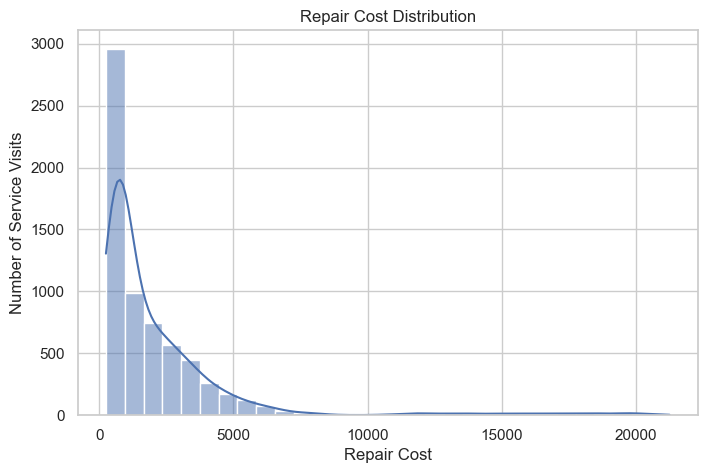

In [16]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Repair_Cost"],
    bins=30,
    kde=True
)

plt.title("Repair Cost Distribution")
plt.xlabel("Repair Cost")
plt.ylabel("Number of Service Visits")

plt.show()

In [17]:
repair_cost_skew = df["Repair_Cost"].skew()

print(f"Repair Cost Skewness: {repair_cost_skew:.2f}")

Repair Cost Skewness: 3.84


In [18]:
df["Turnaround_Time_Days"].describe()

count    6583.000000
mean        1.072535
std         1.596433
min         0.060000
25%         0.320000
50%         0.580000
75%         1.070000
max        14.040000
Name: Turnaround_Time_Days, dtype: float64

In [19]:
print(
    f"Mean   : {df['Turnaround_Time_Days'].mean():.2f} days"
)

print(
    f"Median : {df['Turnaround_Time_Days'].median():.2f} days"
)

print(
    f"Min    : {df['Turnaround_Time_Days'].min():.2f} days"
)

print(
    f"Max    : {df['Turnaround_Time_Days'].max():.2f} days"
)

Mean   : 1.07 days
Median : 0.58 days
Min    : 0.06 days
Max    : 14.04 days


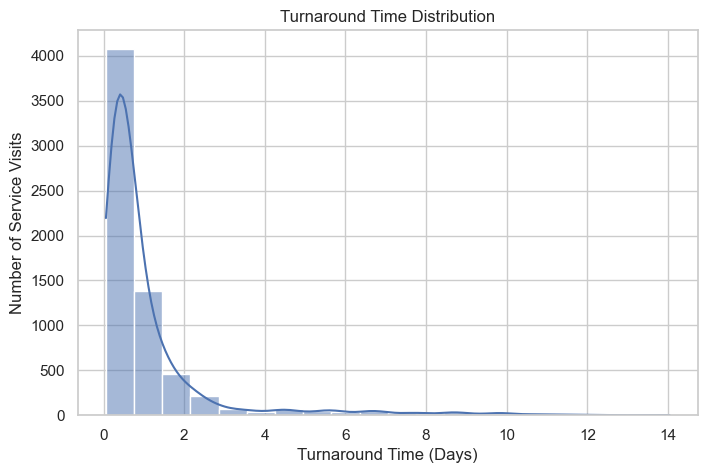

In [20]:
plt.figure(figsize=(8, 5))

sns.histplot(
    df["Turnaround_Time_Days"],
    bins=20,
    kde=True
)

plt.title("Turnaround Time Distribution")
plt.xlabel("Turnaround Time (Days)")
plt.ylabel("Number of Service Visits")

plt.show()

In [21]:
tat_skew = df["Turnaround_Time_Days"].skew()

print(f"Turnaround Time Skewness: {tat_skew:.2f}")

Turnaround Time Skewness: 3.76


In [22]:
df["Is_Delayed"].value_counts()

Is_Delayed
False    5721
True      862
Name: count, dtype: int64

In [23]:
delay_percentage = (
    df["Is_Delayed"]
    .value_counts(normalize=True)
    * 100
)

delay_percentage

Is_Delayed
False    86.905666
True     13.094334
Name: proportion, dtype: float64

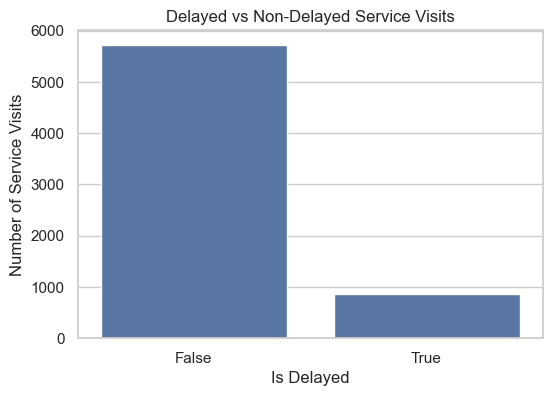

In [24]:
plt.figure(figsize=(6, 4))

sns.countplot(
    data=df,
    x="Is_Delayed"
)

plt.title("Delayed vs Non-Delayed Service Visits")
plt.xlabel("Is Delayed")
plt.ylabel("Number of Service Visits")

plt.show()

In [25]:
delay_rate = df["Is_Delayed"].mean() * 100

print(f"Overall Delay Rate: {delay_rate:.2f}%")

Overall Delay Rate: 13.09%


In [26]:
issue_counts = df["Issue_Family"].value_counts()

issue_counts

Issue_Family
General Service    2016
Brake              1315
Tyre               1099
Electrical          766
Battery             657
Suspension          480
Motor               250
Name: count, dtype: int64

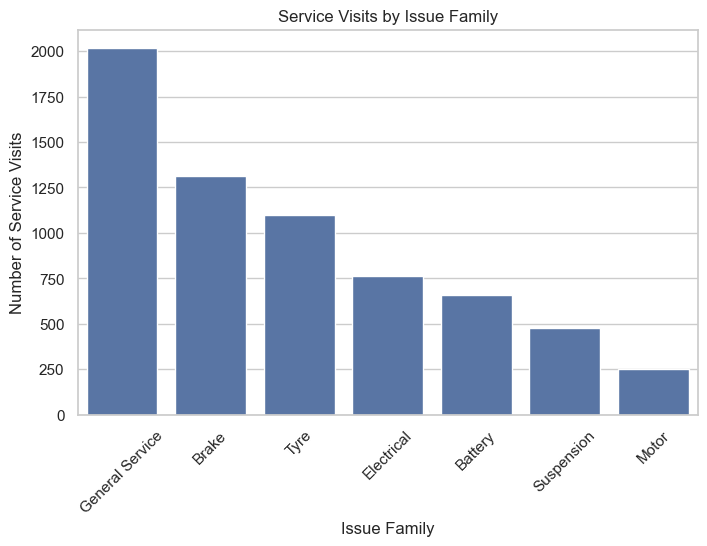

In [27]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="Issue_Family",
    order=df["Issue_Family"].value_counts().index
)

plt.title("Service Visits by Issue Family")
plt.xlabel("Issue Family")
plt.ylabel("Number of Service Visits")

plt.xticks(rotation=45)

plt.show()

In [29]:
issue_cost = (
    df.groupby("Issue_Family")["Repair_Cost"]
      .mean()
      .sort_values(ascending=False)
)

issue_cost

Issue_Family
Battery            7129.718417
Motor              4146.280000
Suspension         3021.318750
Electrical         2164.263708
Brake              1688.635741
Tyre               1604.154686
General Service     669.265873
Name: Repair_Cost, dtype: float64

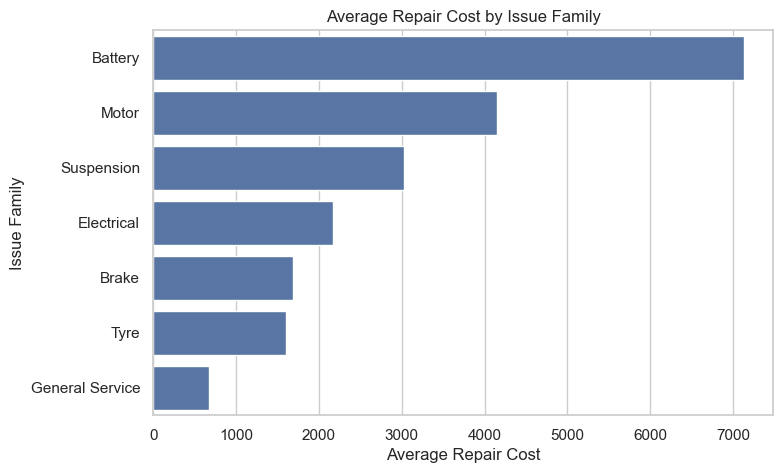

In [30]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=issue_cost.values,
    y=issue_cost.index
)

plt.title("Average Repair Cost by Issue Family")
plt.xlabel("Average Repair Cost")
plt.ylabel("Issue Family")

plt.show()

In [31]:
complexity_cost = (
    df.groupby("Repair_Complexity")["Repair_Cost"]
      .mean()
      .sort_values()
)

complexity_cost

Repair_Complexity
1     701.216345
2    2318.106195
3    6372.594771
Name: Repair_Cost, dtype: float64

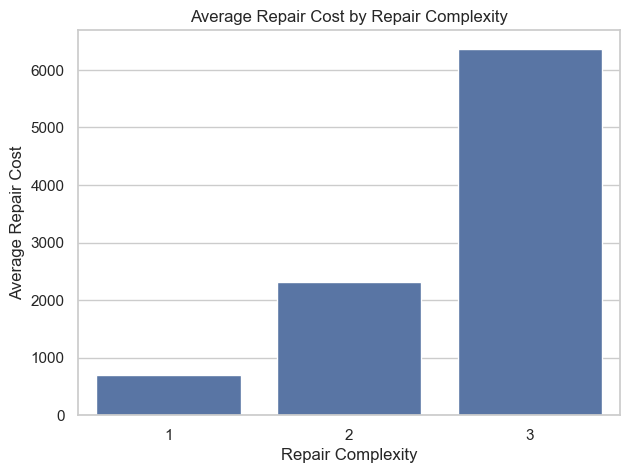

In [32]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=complexity_cost.index,
    y=complexity_cost.values
)

plt.title("Average Repair Cost by Repair Complexity")
plt.xlabel("Repair Complexity")
plt.ylabel("Average Repair Cost")

plt.show()

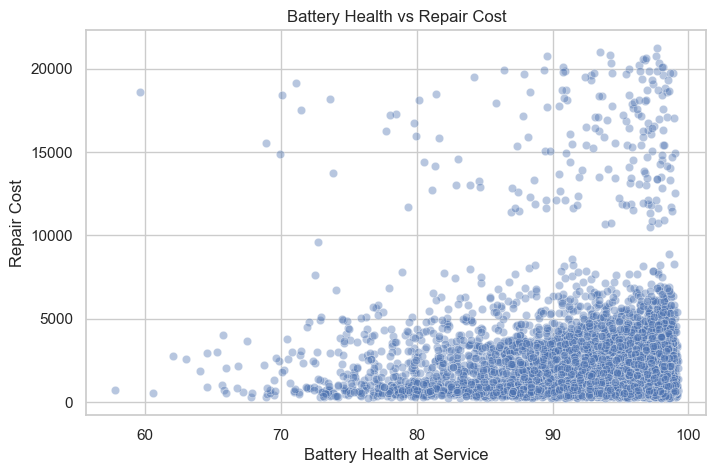

In [33]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Battery_Health_at_Service",
    y="Repair_Cost",
    alpha=0.4
)

plt.title("Battery Health vs Repair Cost")
plt.xlabel("Battery Health at Service")
plt.ylabel("Repair Cost")

plt.show()

In [35]:
print(
    df["Battery_Health_at_Service"]
      .corr(df["Repair_Cost"])
)

-0.01563687493731153


In [36]:
df["Parts_Available"].value_counts()

Parts_Available
False    4227
True     2356
Name: count, dtype: int64

In [37]:
parts_tat = (
    df.groupby("Parts_Available")["Turnaround_Time_Days"]
      .mean()
)

parts_tat

Parts_Available
False    1.239936
True     0.772194
Name: Turnaround_Time_Days, dtype: float64

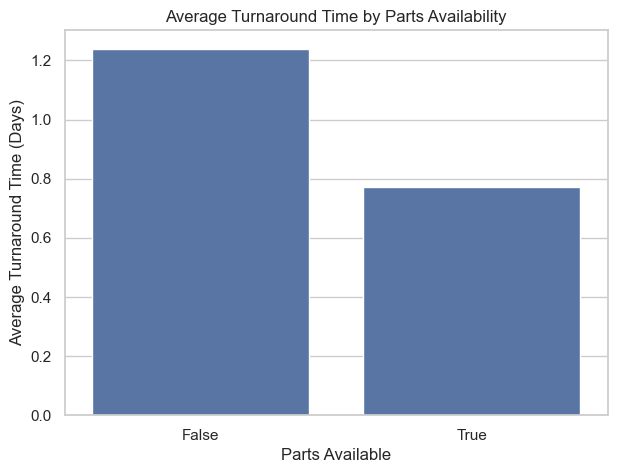

In [38]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=parts_tat.index,
    y=parts_tat.values
)

plt.title("Average Turnaround Time by Parts Availability")
plt.xlabel("Parts Available")
plt.ylabel("Average Turnaround Time (Days)")

plt.show()

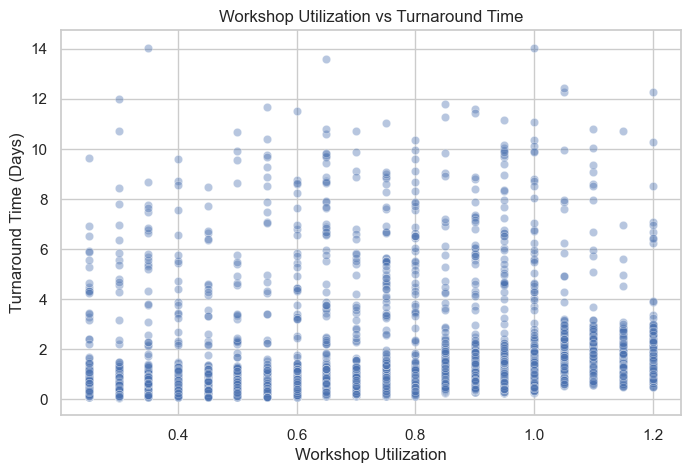

In [39]:
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=df,
    x="Workshop_Utilization",
    y="Turnaround_Time_Days",
    alpha=0.4
)

plt.title("Workshop Utilization vs Turnaround Time")
plt.xlabel("Workshop Utilization")
plt.ylabel("Turnaround Time (Days)")

plt.show()


In [40]:
correlation = (
    df["Workshop_Utilization"]
      .corr(df["Turnaround_Time_Days"])
)

print(
    f"Correlation: {correlation:.2f}"
)

Correlation: 0.21


In [41]:
delay_by_parts = (
    df.groupby("Parts_Available")["Is_Delayed"]
      .mean()
      .mul(100)
)

delay_by_parts

Parts_Available
False    14.620298
True     10.356537
Name: Is_Delayed, dtype: float64

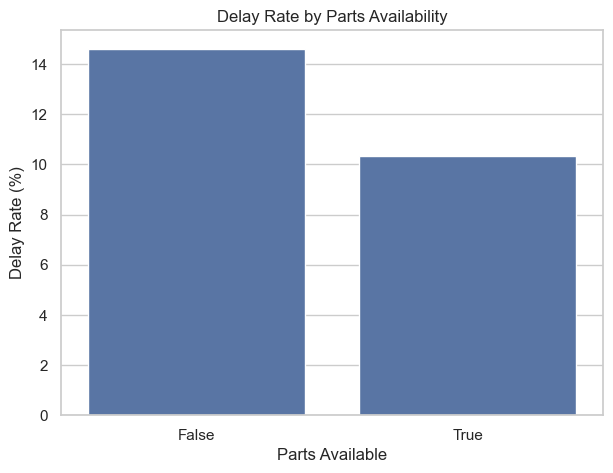

In [42]:
plt.figure(figsize=(7, 5))

sns.barplot(
    x=delay_by_parts.index,
    y=delay_by_parts.values
)

plt.title("Delay Rate by Parts Availability")
plt.xlabel("Parts Available")
plt.ylabel("Delay Rate (%)")

plt.show()

In [43]:
correlation_matrix = df[
    [
        "Battery_Health_at_Service",
        "Repair_Complexity",
        "Workshop_Utilization",
        "Parts_Available",
        "Repair_Cost",
        "Turnaround_Time_Days"
    ]
].corr()

correlation_matrix

,Battery_Health_at_Service,Repair_Complexity,Workshop_Utilization,Parts_Available,Repair_Cost,Turnaround_Time_Days
Battery_Health_at_Service,1.000000,-0.005623,-0.017105,-0.025112,-0.015637,-0.014415
Repair_Complexity,-0.005623,1.000000,0.007917,0.290342,0.672783,0.401555
Workshop_Utilization,-0.017105,0.007917,1.000000,0.004622,0.007261,0.207858
Parts_Available,-0.025112,0.290342,0.004622,1.000000,0.302241,-0.140465
Repair_Cost,-0.015637,0.672783,0.007261,0.302241,1.000000,0.449379
Turnaround_Time_Days,-0.014415,0.401555,0.207858,-0.140465,0.449379,1.000000


In [44]:
correlation_matrix = df[
    [
        "Battery_Health_at_Service",
        "Workshop_Utilization",
        "Repair_Cost",
        "Turnaround_Time_Days"
    ]
].corr()

correlation_matrix

,Battery_Health_at_Service,Workshop_Utilization,Repair_Cost,Turnaround_Time_Days
Battery_Health_at_Service,1.000000,-0.017105,-0.015637,-0.014415
Workshop_Utilization,-0.017105,1.000000,0.007261,0.207858
Repair_Cost,-0.015637,0.007261,1.000000,0.449379
Turnaround_Time_Days,-0.014415,0.207858,0.449379,1.000000


## EDA Conclusions

### Data Quality

- The dataset contains 6,583 service visits and 41 features.
- No missing values were found.
- No exact duplicate rows were found.
- `Workshop_Capacity` was identified as a constant feature and will be reviewed during feature engineering.

### Business Insights

- General Service is the most common service issue.
- Motor-related services are the least frequent.
- Battery-related services have the highest average repair cost.
- General Service has the lowest average repair cost.
- Higher repair complexity is associated with higher repair cost.
- Battery health has a negative relationship with repair cost.
- Unavailable parts are associated with higher turnaround time.
- Higher workshop utilization is associated with higher turnaround time.
- Unavailable parts are associated with a higher delay rate.

### Modeling Implications

The EDA suggests that issue type, repair complexity, battery condition, parts availability, and workshop conditions may contain useful predictive information.

These observations will guide feature engineering and model development, but relationships observed during EDA do not by themselves establish causality.